# Import dependencies

In [1]:
import os
import torch
import torchaudio
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

torch.device("cuda" if torch.cuda.is_available() else "cpu")

True
NVIDIA GeForce RTX 5090 Laptop GPU


device(type='cuda')

# Load Dataset and split into Testing and Training

In [2]:
from coffee_speech_dataset import CoffeeSpeechDataset
from torch.utils.data import DataLoader
import torchaudio.transforms as T

# Define transform (optional but recommended)
transform = T.MelSpectrogram(
    sample_rate=16000,
    n_mels=64,
    n_fft=400,       # 25ms window — standard for speech
    hop_length=160,  # 10ms hop — fine enough to catch short phonemes
    f_min=20,        # cut sub-bass noise
    f_max=8000,      # Nyquist for 16kHz, no energy above this anyway
)

# Load dataset
dataset = CoffeeSpeechDataset(
    root_dir="data",
    sample_rate=16000,
    transform=transform
)

# Create DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=4
)

# Check dataset
print(f"Classes:  {dataset.label_names}")
print(f"Samples:  {len(dataset)}")
print(f"Batches:  {len(dataloader)}")




Classes:  ['kaffee_gross', 'kaffee_klein', 'noise', 'ok_fernando']
Samples:  9000
Batches:  9000


In [3]:
from collections import Counter

label_counts = Counter(dataset.labels)
print("Class distribution:")
for i, name in enumerate(dataset.label_names):
    print(f"  {name}: {label_counts[i]} samples")

Class distribution:
  kaffee_gross: 2250 samples
  kaffee_klein: 2250 samples
  noise: 2250 samples
  ok_fernando: 2250 samples


In [4]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=4)

print(f"Train: {len(train_set)} | Val: {len(val_set)}")

Train: 7200 | Val: 1800


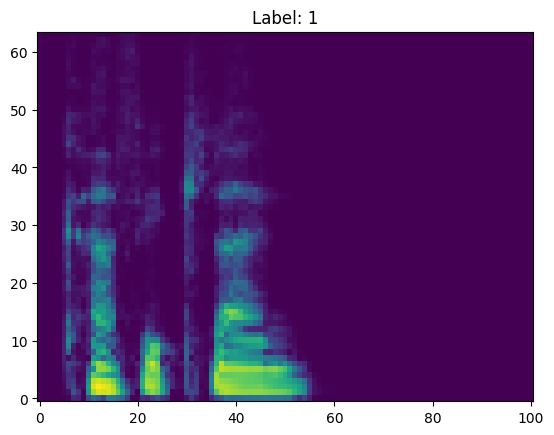

In [5]:
import matplotlib.pyplot as plt
mel, label = next(iter(train_loader))
plt.imshow(mel[0][0].cpu().numpy(), aspect='auto', origin='lower')
plt.title(f"Label: {label[0]}")
plt.show()

# Minimal CNN Architecture

In [6]:
class DSCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.model = nn.Sequential(
            # Standard conv first
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            # Depthwise separable blocks
            self._ds_block(32, 32),
            self._ds_block(32, 32),
            self._ds_block(32, 32),
            self._ds_block(32, 32),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(32, num_classes)
        )

    def _ds_block(self, in_ch, out_ch):
        return nn.Sequential(
            # Depthwise
            nn.Conv2d(in_ch, in_ch, kernel_size=3, padding=1, groups=in_ch),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(),
            # Pointwise
            nn.Conv2d(in_ch, out_ch, kernel_size=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.model(x)

Checking parameter count and size

In [7]:
model = DSCNN(num_classes=4)

total_params = sum(p.numel() for p in model.parameters())
size_kb = total_params * 4 / 1024  # float32

print(f"Parameters: {total_params:,}")
print(f"Size (float32): {size_kb:.1f} KB")
print(f"Size (int8 quantized): {size_kb/4:.1f} KB")  # after quantization

Parameters: 6,532
Size (float32): 25.5 KB
Size (int8 quantized): 6.4 KB


# Training Loop

In [8]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(50):
    model.train()
    running_loss = 0.0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.2641
Epoch 2, Loss: 1.0946
Epoch 3, Loss: 1.0100
Epoch 4, Loss: 0.9512
Epoch 5, Loss: 0.9075
Epoch 6, Loss: 0.8730
Epoch 7, Loss: 0.8390
Epoch 8, Loss: 0.8025
Epoch 9, Loss: 0.7708
Epoch 10, Loss: 0.7405
Epoch 11, Loss: 0.7114
Epoch 12, Loss: 0.6823
Epoch 13, Loss: 0.6517
Epoch 14, Loss: 0.6251
Epoch 15, Loss: 0.5953
Epoch 16, Loss: 0.5747
Epoch 17, Loss: 0.5527
Epoch 18, Loss: 0.5317
Epoch 19, Loss: 0.5146
Epoch 20, Loss: 0.4947
Epoch 21, Loss: 0.4752
Epoch 22, Loss: 0.4622
Epoch 23, Loss: 0.4487
Epoch 24, Loss: 0.4317
Epoch 25, Loss: 0.4181
Epoch 26, Loss: 0.4033
Epoch 27, Loss: 0.3913
Epoch 28, Loss: 0.3762
Epoch 29, Loss: 0.3683
Epoch 30, Loss: 0.3498
Epoch 31, Loss: 0.3447
Epoch 32, Loss: 0.3326
Epoch 33, Loss: 0.3193
Epoch 34, Loss: 0.3061
Epoch 35, Loss: 0.2995
Epoch 36, Loss: 0.2906
Epoch 37, Loss: 0.2766
Epoch 38, Loss: 0.2677
Epoch 39, Loss: 0.2583
Epoch 40, Loss: 0.2531
Epoch 41, Loss: 0.2408
Epoch 42, Loss: 0.2301
Epoch 43, Loss: 0.2245
Epoch 44, Loss: 0.21

# Confusion Matrix

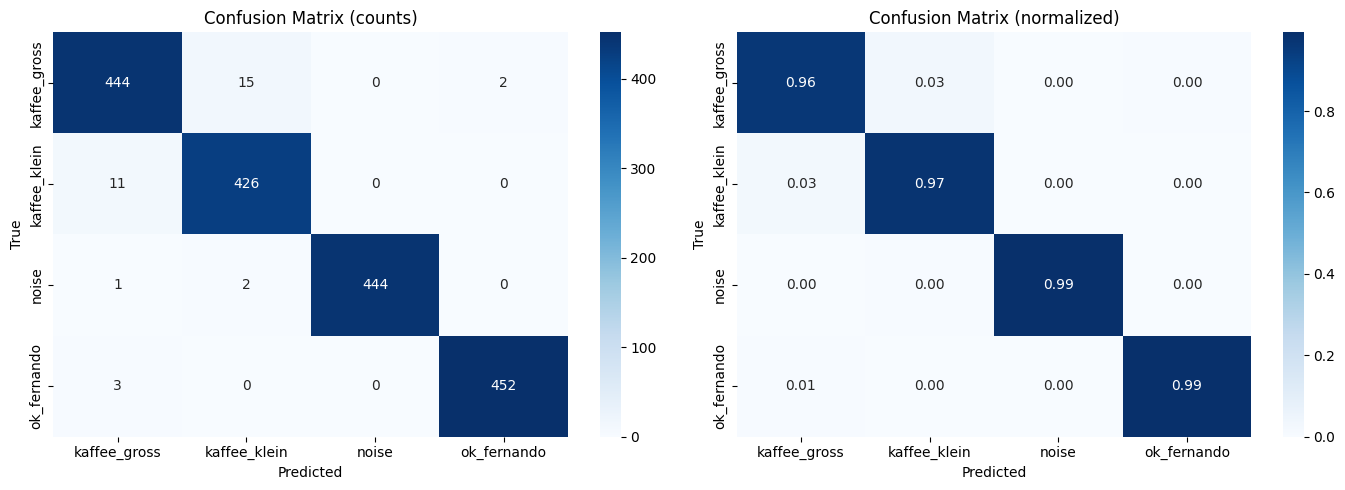


Per-class accuracy:
  kaffee_gross: 96.3%
  kaffee_klein: 97.5%
  noise: 99.3%
  ok_fernando: 99.3%


In [9]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for features, labels in val_loader:
        features = features.to(device)
        outputs = model(features)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=dataset.label_names,
            yticklabels=dataset.label_names,
            ax=axes[0])
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=dataset.label_names,
            yticklabels=dataset.label_names,
            ax=axes[1])
axes[1].set_title("Confusion Matrix (normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Per class accuracy
print("\nPer-class accuracy:")
for i, name in enumerate(dataset.label_names):
    acc = cm_normalized[i, i] * 100
    print(f"  {name}: {acc:.1f}%")

# Save the model

In [10]:
model.eval()
torch.save(model.state_dict(), 'model_files/kws_model.pt')